# **AI Advanced Ahmed Yousrey Course Practice**

---
# **DAY 5 — Financial Transaction Anomaly Detector**
---

## STEP 1 — Importing Libraries

---

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import precision_score ,recall_score ,f1_score, confusion_matrix, classification_report

---
## STEP 2 — Importing database

---

In [116]:

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
df = pd.read_csv('/content/drive/MyDrive/data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [118]:
df.shape

(284807, 31)

---
## STEP 3 — EDA

---

In [119]:
df.shape

(284807, 31)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [121]:
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [122]:
df.duplicated().sum()

np.int64(1081)

In [123]:
df[df.duplicated(keep=False)]["Class"].value_counts()

,count
Class,
0,1822
1,32


In [124]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 284807
Duplicate rows: 1081
Unique rows: 283726


In [125]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [126]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


---
## STEP 4 — PREPROCESSING
---

**1.seperate target**

In [127]:
x = df.drop("Class", axis=1)

**2.drop duplicates**

In [128]:
df = df.drop_duplicates().reset_index(drop=True)
df.dropna(subset=['Class'], inplace=True)
y = df["Class"]
features = df.drop("Class", axis=1)

In [129]:
print("Rows after removing duplicates:", len(df))
print(df["Class"].value_counts())

Rows after removing duplicates: 283726
Class
0    283253
1       473
Name: count, dtype: int64


**3.Understand feature distributions**

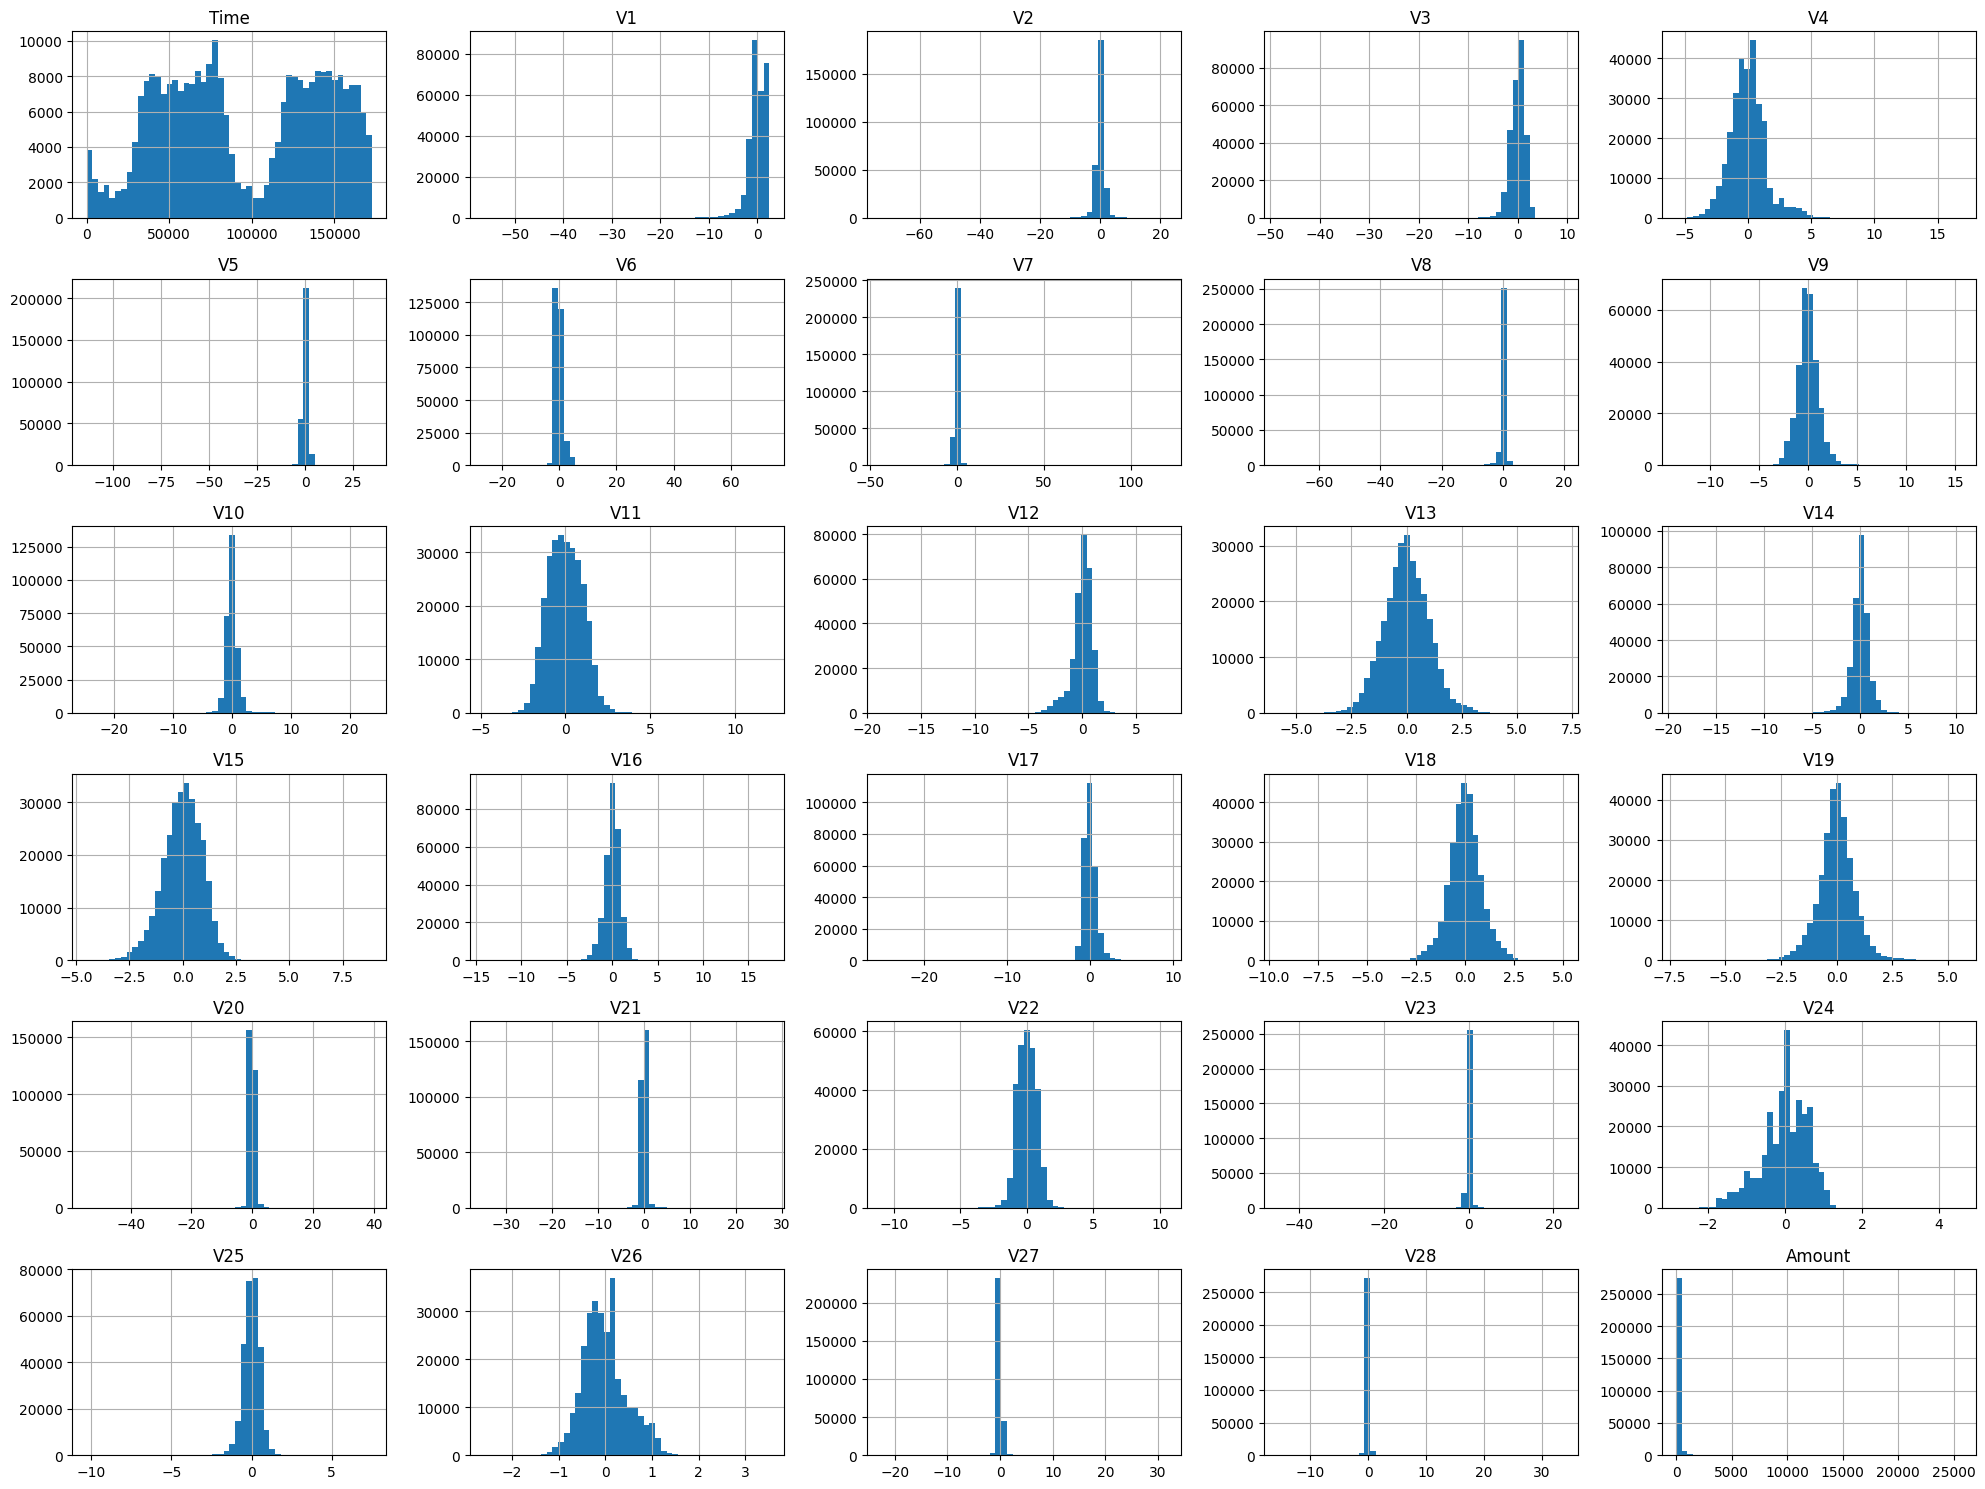

In [130]:
features.hist(
    figsize=(20, 15),
    bins=50
)

plt.tight_layout()
plt.show()

Most features show relatively centered and symmetric distributions with no strong skewness or long tails. No major multimodal patterns were observed, except for time-related behavior, which is expected. Therefore, no additional distribution-based transformation is immediately required. However, rare observations may still represent anomalies even when the overall feature distributions appear well-behaved.

---
4.scaling

In [131]:
features.describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
Time,0.000000,172792.000000,94811.077600,47481.047891
V1,-56.407510,2.454930,0.005917,1.948026
V2,-72.715728,22.057729,-0.004135,1.646703
V3,-48.325589,9.382558,0.001613,1.508682
V4,-5.683171,16.875344,-0.002966,1.414184
V5,-113.743307,34.801666,0.001828,1.377008
V6,-26.160506,73.301626,-0.001139,1.331931
V7,-43.557242,120.589494,0.001801,1.227664
V8,-73.216718,20.007208,-0.000854,1.179054
V9,-13.434066,15.594995,-0.001596,1.095492


In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

In [133]:
features_scaled = pd.DataFrame(
    features_scaled,
    columns=features.columns,
    index=features.index
)

In [134]:
features_scaled.describe().T[['mean', 'std']]

,mean,std
Time,1.218105e-16,1.000002
V1,-5.659779e-17,1.000002
V2,-2.404154e-18,1.000002
V3,-1.121939e-16,1.000002
V4,1.422458e-17,1.000002
V5,3.365816e-17,1.000002
V6,4.808308e-18,1.000002
V7,-1.883254e-17,1.000002
V8,-1.141973e-17,1.000002
V9,-3.190513e-17,1.000002



The original V1–V28 features were already standardized individually, but Time and Amount were on very different scales. Re-scaling all features together was necessary to ensure distance-based anomaly detection methods such as LOF treat features comparably.

---

---
## STEP 5 — Anomaly Detector
---

1.Isolation Forest

In [135]:
iso_forest = IsolationForest(
    contamination=0.0017,
    random_state=42,
    n_estimators=100
)

iso_forest.fit(features_scaled)

IsolationForest(contamination=0.0017, random_state=42)

In [136]:
iso_pred = iso_forest.predict(features_scaled)

iso_anomaly = (iso_pred == -1).astype(int)

print("Detected anomalies:", iso_anomaly.sum())
print("Anomaly rate:", iso_anomaly.mean())

Detected anomalies: 483
Anomaly rate: 0.0017023466301995588


In [137]:
y = df["Class"]
features = df.drop("Class", axis=1)

In [138]:
print(confusion_matrix(y, iso_anomaly))
print(classification_report(y, iso_anomaly))

[[282847    406]
 [   396     77]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    283253
           1       0.16      0.16      0.16       473

    accuracy                           1.00    283726
   macro avg       0.58      0.58      0.58    283726
weighted avg       1.00      1.00      1.00    283726



Isolation Forest Takeaway

Isolation Forest detected 483 transactions as anomalies, while there were 473 actual fraud transactions after removing duplicates.

The model correctly detected 77 fraud transactions, but it also classified 406 normal transactions as anomalies. This resulted in approximately 16% precision, 16% recall, and 16% F1-score for the fraud class.

The main takeaway is that Isolation Forest does not directly detect fraud. It identifies transactions that are statistically unusual or easy to isolate. Therefore, an anomaly is not necessarily fraud, and a fraud transaction is not necessarily an anomaly.

The high overall accuracy is misleading because the dataset is highly imbalanced, with fraud representing only a very small percentage of transactions. Precision, recall, and F1-score for the fraud class are more meaningful evaluation metrics.

The experiment also showed that setting contamination to 0.0017, based on the actual fraud rate, does not necessarily produce the best anomaly detection performance. Different contamination values should be tested to understand their effect on fraud detection and false positives.

---

**2.contamination**

In [139]:
contamination_values = [0.001, 0.002, 0.005, 0.01]

for contamination in contamination_values:

    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )

    iso_forest.fit(features_scaled)

    predictions = iso_forest.predict(features_scaled)
    predictions = (predictions == -1).astype(int)

    precision = precision_score(y, predictions)
    recall = recall_score(y, predictions)
    f1 = f1_score(y, predictions)

    print(f"Contamination: {contamination}")
    print(f"Detected anomalies: {predictions.sum()}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("-" * 40)

Contamination: 0.001
Detected anomalies: 284
Precision: 0.1655
Recall: 0.0994
F1-score: 0.1242
----------------------------------------
Contamination: 0.002
Detected anomalies: 568
Precision: 0.1690
Recall: 0.2030
F1-score: 0.1844
----------------------------------------
Contamination: 0.005
Detected anomalies: 1419
Precision: 0.1247
Recall: 0.3742
F1-score: 0.1871
----------------------------------------
Contamination: 0.01
Detected anomalies: 2838
Precision: 0.0881
Recall: 0.5285
F1-score: 0.1510
----------------------------------------


Contamination Experiment Takeaway

Testing different contamination values showed a clear trade-off between precision and recall.

As contamination increased, Isolation Forest detected more transactions as anomalies. This increased fraud recall from 9.94% at contamination = 0.001 to 52.85% at contamination = 0.01.

However, precision decreased from 16.55% to 8.81%, meaning that a larger number of normal transactions were incorrectly classified as anomalies.

The highest F1-score was achieved at contamination = 0.005 with an F1-score of 18.71%.

Therefore, contamination = 0.005 provided the best balance between precision and recall among the tested values, although the overall fraud detection performance remained limited.

This experiment demonstrates that contamination is an important hyperparameter in Isolation Forest, and increasing it does not automatically improve anomaly detection because it increases both detected fraud cases and false positives.
---

**3.LOF (Local Outlier Factor)**

In [140]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.005
)

lof_pred = lof.fit_predict(features_scaled)

lof_anomaly = (lof_pred == -1).astype(int)

In [141]:
print("Detected anomalies:", lof_anomaly.sum())

Detected anomalies: 1419


In [142]:

print("Precision:", precision_score(y, lof_anomaly))
print("Recall:", recall_score(y, lof_anomaly))
print("F1-score:", f1_score(y, lof_anomaly))

Precision: 0.0021141649048625794
Recall: 0.006342494714587738
F1-score: 0.003171247357293869


LOF Takeaway

LOF performed significantly worse than Isolation Forest on this dataset.

With n_neighbors=20 and contamination=0.005,

 LOF achieved only

  0.21% precision,

  0.63% recall,
  
  and 0.32% F1-score
  
  for fraud detection.

This means that LOF was unable to effectively identify fraudulent transactions based on local density.

Compared with Isolation Forest, which achieved 12.47% precision, 37.42% recall, and 18.71% F1-score under the same contamination value, Isolation Forest was clearly more effective for this dataset.

Therefore, Isolation Forest is the better anomaly detection approach between the two models tested.

**4.Elliptic Envelope**

In [ ]:
from sklearn.covariance import EllipticEnvelope

ee = EllipticEnvelope(
    contamination=0.005,
    random_state=42,
    support_fraction=0.999
)

ee.fit(features_scaled)

ee_pred = ee.predict(features_scaled)
ee_anomaly = (ee_pred == -1).astype(int)

print("Detected anomalies:", ee_anomaly.sum())

In [ ]:
print("Precision:", precision_score(y, ee_anomaly))
print("Recall:", recall_score(y, ee_anomaly))
print("F1-score:", f1_score(y, ee_anomaly))
print()
print(classification_report(y, ee_anomaly))

Elliptic Envelope Takeaway

Elliptic Envelope was the best-performing method in this project.

With contamination = 0.005 and support_fraction = 0.999, the model achieved:

- Precision: 26.50%
- Recall: 79.49%
- F1-score: 39.75%

This means the model correctly detected nearly 80% of all actual fraud transactions without using any labels during training.

The reason Elliptic Envelope performs well here is that the V1–V28 features are PCA-transformed outputs from real bank data. PCA tends to produce approximately Gaussian distributions, which is exactly the assumption Elliptic Envelope relies on. It fits a multivariate Gaussian to the data and uses Mahalanobis distance to measure how far each point is from the center of the normal cluster. Points with high Mahalanobis distance are flagged as anomalies.

Compared to Isolation Forest (F1 = 19.56%) and LOF (F1 = 0.32%), Elliptic Envelope achieved more than double the F1-score of the next best method, making it the clear winner for this dataset and feature structure.

**5.IQR (Interquartile Range)**

In [ ]:
Q1 = features['Amount'].quantile(0.25)
Q3 = features['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}')
print(f'Lower bound: {lower_bound:.2f} | Upper bound: {upper_bound:.2f}')

iqr_outliers = ((features['Amount'] < lower_bound) | (features['Amount'] > upper_bound)).astype(int)

print('Detected anomalies:', iqr_outliers.sum())

In [ ]:
print('Precision:', precision_score(y, iqr_outliers))
print('Recall:', recall_score(y, iqr_outliers))
print('F1-score:', f1_score(y, iqr_outliers))

IQR Takeaway

IQR detected 31,685 transactions as anomalies based solely on the Amount feature.

- Precision: 0.27%
- Recall: 18.39%
- F1-score: 0.54%

The results are poor because IQR only examines one feature at a time. Fraud is not simply about having an unusually high or low transaction amount. A fraudulent transaction can have a perfectly normal Amount while being anomalous across the combination of V1–V28 features.

IQR also flagged 31,685 transactions — many of which are just high-value legitimate purchases. The false positive rate is far too high to be useful in production.

Statistical methods like IQR are best used as a quick sanity check or for detecting obvious data quality issues, not as a standalone fraud detector.

**6.Z-Score**

In [ ]:
z_scores = np.abs((features['Amount'] - features['Amount'].mean()) / features['Amount'].std())

threshold = 3
zscore_outliers = (z_scores > threshold).astype(int)

print(f'Threshold: {threshold}')
print(f'Detected anomalies: {zscore_outliers.sum()}')

In [ ]:
print('Precision:', precision_score(y, zscore_outliers))
print('Recall:', recall_score(y, zscore_outliers))
print('F1-score:', f1_score(y, zscore_outliers))

Z-Score Takeaway

Z-Score with threshold = 3 detected 4,063 transactions as anomalies based on the Amount feature.

- Precision: 0.27%
- Recall: 2.33%
- F1-score: 0.49%

Z-Score performed even worse than IQR for fraud detection. The threshold of 3 standard deviations only flags extreme Amount values. Most fraudulent transactions have unremarkable amounts that fall well within 3 standard deviations of the mean.

Like IQR, Z-Score is a single-feature method and cannot capture the multi-dimensional patterns that define fraud. Both statistical methods confirm that Amount alone is not a reliable signal for detecting fraud in this dataset.

---
## STEP 6 — Method Comparison
---

In [ ]:
results = {
    'IQR':               {'Precision': precision_score(y, iqr_outliers),     'Recall': recall_score(y, iqr_outliers),     'F1': f1_score(y, iqr_outliers)},
    'Z-Score':           {'Precision': precision_score(y, zscore_outliers),  'Recall': recall_score(y, zscore_outliers),  'F1': f1_score(y, zscore_outliers)},
    'Isolation Forest':  {'Precision': precision_score(y, iso_anomaly),      'Recall': recall_score(y, iso_anomaly),      'F1': f1_score(y, iso_anomaly)},
    'LOF':               {'Precision': precision_score(y, lof_anomaly),      'Recall': recall_score(y, lof_anomaly),      'F1': f1_score(y, lof_anomaly)},
    'Elliptic Envelope': {'Precision': precision_score(y, ee_anomaly),       'Recall': recall_score(y, ee_anomaly),       'F1': f1_score(y, ee_anomaly)},
}

results_df = pd.DataFrame(results).T
print(results_df.to_string())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = list(results.keys())
colors = ['#d9534f', '#d9534f', '#5bc0de', '#5bc0de', '#5cb85c']

for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    values = [results[m][metric] for m in methods]
    bars = ax.barh(methods, values, color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0, max(values) * 1.3)
    for i, v in enumerate(values):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Anomaly Detection Method Comparison — Fraud Detection Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Method Comparison Takeaway

| Method | Precision | Recall | F1 |
|---|---|---|---|
| IQR | 0.27% | 18.39% | 0.54% |
| Z-Score | 0.27% | 2.33% | 0.49% |
| Isolation Forest | 13.04% | 39.11% | 19.56% |
| LOF | 0.21% | 0.63% | 0.32% |
| **Elliptic Envelope** | **26.50%** | **79.49%** | **39.75%** |

**Winner: Elliptic Envelope** with F1 = 39.75% and Recall = 79.49%.

The key pattern is clear: statistical methods (IQR, Z-Score) that operate on a single feature cannot detect multi-dimensional fraud patterns. ML methods that consider all 30 features together dramatically outperform them.

Among the ML methods, Elliptic Envelope benefits from the Gaussian structure of the PCA-transformed V features. Isolation Forest is the second-best option and is more flexible — it does not assume any particular distribution. LOF struggled because fraud in this dataset is not always a local density outlier.

In a real production system, Elliptic Envelope and Isolation Forest would likely be combined — flagging a transaction if either model detects it as anomalous — to maximize recall.